# 05 · Regimes and flexibility (RQ3 and RQ4)

Chapter 4 of *Mapping the Consumption Gap*, part 2. The Duke-style curtailment-enabled headroom replicated on CAISO hourly load 2019-2025 (RQ4), the energy-side argument from negative-price hours and curtailment, the crosswalk of six data and measurement regimes with a common taxonomy and California's headline number under each counting rule (RQ3), and the optional emissions comparison of a flat versus a curtailable load.

Outputs are produced by `scripts/run_chapter4.py` from `src/ch4_gap.py` and `src/ch4_regimes.py`; this notebook displays them.

| Step | Sources (manifest ids) |
|---|---|
| Headroom | `ciso_hourly_2019_2025_clean.parquet` (chapter 1, EIA-930 CISO adjusted demand), `duke_rethinking_load_growth_2025_mirror` (method and CAISO values) |
| Energy side | chapter 1 price statistics (`caiso_oasis` day-ahead LMPs), chapter 3 curtailment (`caiso_curtailments_monthly_csv`) |
| Crosswalk | `cec_dc_methodology_memo_2026`, `cec_tn268459`, ERCOT decks and monthlies, `pjm_lar_summary_2025_11_24`, `pjm_2026_load_report_tables`, `eia_press585_dc_pilot_surveys`, `texas_sb6_2025_enrolled`, `caiso_comments_ferc_rm26_4_2025_11`, `nerc_rm26_4_accelerated_plan_2026_03`, `ferc_news_2026_04_16_large_load`, `ferc_news_2026_06_18_show_cause` |
| Emissions | `caiso_co2_intensity_hourly.parquet` (chapter 1, CAISO Today's Outlook) |


In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))
import pandas as pd, numpy as np
from IPython.display import Image, display
from src.paths import PROCESSED, FIGURES
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 90)
def show(name): display(Image(filename=str(FIGURES / f"{name}.png")))
def table(name, **kw): return pd.read_csv(PROCESSED / f"{name}.csv", **kw).convert_dtypes()  # integer-valued columns display as integers

## 1. Curtailment-enabled headroom (RQ4)

Duke's method: add a constant load L to every hour, count as curtailment any excess of demand plus L over the seasonal peak threshold (the maximum winter and non-winter demand across all years; for Pacific-coast balancing authorities winter is November to February), average the annual curtailment rate over the years, and goal-seek L for 0.25, 0.5, 1 and 5 percent. Three variants test the season definition and the sample of years.

In [2]:
table("ch4_headroom_summary").round(0)

,limit,headroom_mw,duke_caiso_gw,winter_threshold_mw,summer_threshold_mw,variant
0,0.0,3112.0,4.0,31226,51104,"Duke seasons (Nov-Feb winter), 2019-2025"
1,0.0,3798.0,5.0,31226,51104,"Duke seasons (Nov-Feb winter), 2019-2025"
2,0.0,4641.0,6.0,31226,51104,"Duke seasons (Nov-Feb winter), 2019-2025"
3,0.0,8031.0,<NA>,31226,51104,"Duke seasons (Nov-Feb winter), 2019-2025"
4,0.0,3244.0,4.0,31226,51104,"Dec-Feb winter, 2019-2025"
5,0.0,4023.0,5.0,31226,51104,"Dec-Feb winter, 2019-2025"
6,0.0,4977.0,6.0,31226,51104,"Dec-Feb winter, 2019-2025"
7,0.0,9001.0,<NA>,31226,51104,"Dec-Feb winter, 2019-2025"
8,0.0,11593.0,4.0,<NA>,51104,"single annual threshold, 2019-2025"
9,0.0,13578.0,5.0,<NA>,51104,"single annual threshold, 2019-2025"


In [3]:
h = table("ch4_headroom_detail"); h[h.variant.str.startswith("Duke seasons (Nov")].groupby("limit")[["curtailment_rate", "hours_curtailed", "curtailed_mwh", "share_winter", "hours_below_90pct", "hours_below_75pct", "hours_below_50pct", "max_curtailment_mw"]].mean().round(3)

,curtailment_rate,hours_curtailed,curtailed_mwh,share_winter,hours_below_90pct,hours_below_75pct,hours_below_50pct,max_curtailment_mw
limit,,,,,,,,
0.0025,0.002,94.571,68175.059,0.969,65.0,34.143,10.571,2227.075
0.005,0.005,196.857,166431.563,0.979,134.143,68.286,17.714,2912.429
0.01,0.01,383.429,406807.677,0.985,271.571,144.143,33.714,3755.774
0.05,0.05,1510.714,3520002.463,0.988,1224.857,796.286,236.143,7145.405


In [4]:
h[(h.variant.str.startswith("Duke seasons (Nov")) & (h.limit == 0.005)].round(3)

,limit,year,curtailment_rate,hours_curtailed,curtailed_mwh,share_winter,share_summer,hours_below_90pct,hours_below_75pct,hours_below_50pct,max_curtailment_mw,variant
7,0.005,2019,0.006,197,186926.236,1.0,0.0,147,86,20,3024.714,"Duke seasons (Nov-Feb winter), 2019-2025"
8,0.005,2020,0.004,192,148013.164,1.0,0.0,133,65,6,2184.714,"Duke seasons (Nov-Feb winter), 2019-2025"
9,0.005,2021,0.006,191,208676.45,1.0,0.0,141,89,31,3797.714,"Duke seasons (Nov-Feb winter), 2019-2025"
10,0.005,2022,0.005,192,159081.164,0.855,0.0,133,61,19,3797.714,"Duke seasons (Nov-Feb winter), 2019-2025"
11,0.005,2023,0.003,163,101769.447,1.0,0.0,100,40,0,1685.714,"Duke seasons (Nov-Feb winter), 2019-2025"
12,0.005,2024,0.003,173,103928.591,0.997,0.0,98,36,6,2532.714,"Duke seasons (Nov-Feb winter), 2019-2025"
13,0.005,2025,0.008,270,256625.887,1.0,0.0,187,101,42,3363.714,"Duke seasons (Nov-Feb winter), 2019-2025"


**Year by year.** The phase plan asks for the largest flat addition such that the hours above the historical peak stay under 0.25, 0.5 and 1 percent of each year. That hours criterion is solved in closed form from the sorted margins to the threshold, next to Duke's energy criterion solved year by year, for the Duke seasonal thresholds and for a single all-years peak.

In [5]:
hy = table("ch4_headroom_by_year"); hy.pivot_table(index=["variant", "year"], columns="limit", values=["headroom_hours_criterion_mw", "headroom_energy_criterion_mw"]).round(0)

headroom_energy_criterion_mw                            headroom_hours_criterion_mw                           
limit                                                    0.0025   0.005    0.01     0.05                        0.0025   0.005    0.01     0.05  
variant                       year                                                                                                               
Duke seasons (Nov-Feb winter) 2019                       2954.0   3657.0   4585.0   8299.0                      1945.0   2315.0   2870.0   5040.0
                              2020                       3316.0   3916.0   4784.0   8535.0                      2223.0   2508.0   3102.0   5156.0
                              2021                       2523.0   3466.0   4545.0   8347.0                      1561.0   2071.0   2834.0   5067.0
                              2022                       3193.0   3845.0   4660.0   8029.0                      2001.0   2534.0   3140.0   4885.0
                              2023                       3657.0   4196.0   4898.0   7974.0                      2619.0   2873.0   3315.0   4850.0
                              2024                       3650.0   4173.0   4867.0   7849.0                      2635.0   2945.0   3330.0   4815.0
                              2025                       2433.0   3264.0   4152.0   7331.0                      1345.0   1985.0   2641.0   4438.0
single historical peak        2019                      12128.0  13784.0  16122.0  24933.0                      8995.0   9602.0  10806.0  16353.0
                              2020                      10318.0  12492.0  15355.0  24088.0                      6559.0   8056.0   9811.0  15770.0
                              2021                      12745.0  14255.0  16306.0  24410.0                      9630.0  10438.0  11314.0  15757.0
                              2022                       8401.0  11354.0  14149.0  23037.0                      4992.0   6962.0   9428.0  14719.0
                              2023                      13160.0  15141.0  17666.0  25561.0                      9107.0  10416.0  12041.0  17377.0
                              2024                      10752.0  12705.0  15035.0  23450.0                      7425.0   8506.0  10145.0  15199.0
                              2025                      14436.0  16219.0  18286.0  24577.0                     10454.0  11738.0  13084.0  17324.0

In [6]:
table("ch4_headroom_vs_gap").round(3)

,limit,headroom_mw,duke_caiso_mw,share_of_dc_cec_central,share_of_dc_cec_high,share_of_dc_ercot,share_of_dc_pjm_firm,share_of_dc_upper_bound,share_of_peak_gap_p50,share_of_peak_gap_p95,share_of_upper_bound_peak_gap
0,0.002,3112.361,4200,1.966,0.753,1.918,0.874,0.151,0.434,0.309,0.103
1,0.005,3797.714,5000,2.399,0.918,2.341,1.067,0.184,0.53,0.377,0.126
2,0.01,4641.06,5900,2.932,1.122,2.861,1.304,0.224,0.647,0.461,0.154
3,0.05,8030.691,<NA>,5.073,1.942,4.95,2.256,0.388,1.12,0.798,0.266


In [7]:
table("ch4_energy_side").round(0)

,item,value,unit,midday_share_pct,flexible_1gw_energy_gwh,source
0,"PG&E DLAP hours with negative day-ahead price, 2024",190.0,hours,88.0,190,ch1_price_stats
1,"PG&E DLAP hours with negative day-ahead price, 2025",218.0,hours,94.0,218,ch1_price_stats
2,"SCE DLAP hours with negative day-ahead price, 2024",1131.0,hours,77.0,1131,ch1_price_stats
3,"SCE DLAP hours with negative day-ahead price, 2025",877.0,hours,78.0,877,ch1_price_stats
4,"SDG&E DLAP hours with negative day-ahead price, 2024",989.0,hours,77.0,989,ch1_price_stats
5,"SDG&E DLAP hours with negative day-ahead price, 2025",748.0,hours,80.0,748,ch1_price_stats
6,"NP15 hours with negative day-ahead price, 2024",271.0,hours,86.0,271,ch1_price_stats
7,"NP15 hours with negative day-ahead price, 2025",288.0,hours,94.0,288,ch1_price_stats
8,"SP15 hours with negative day-ahead price, 2024",1169.0,hours,76.0,1169,ch1_price_stats
9,"SP15 hours with negative day-ahead price, 2025",976.0,hours,78.0,976,ch1_price_stats


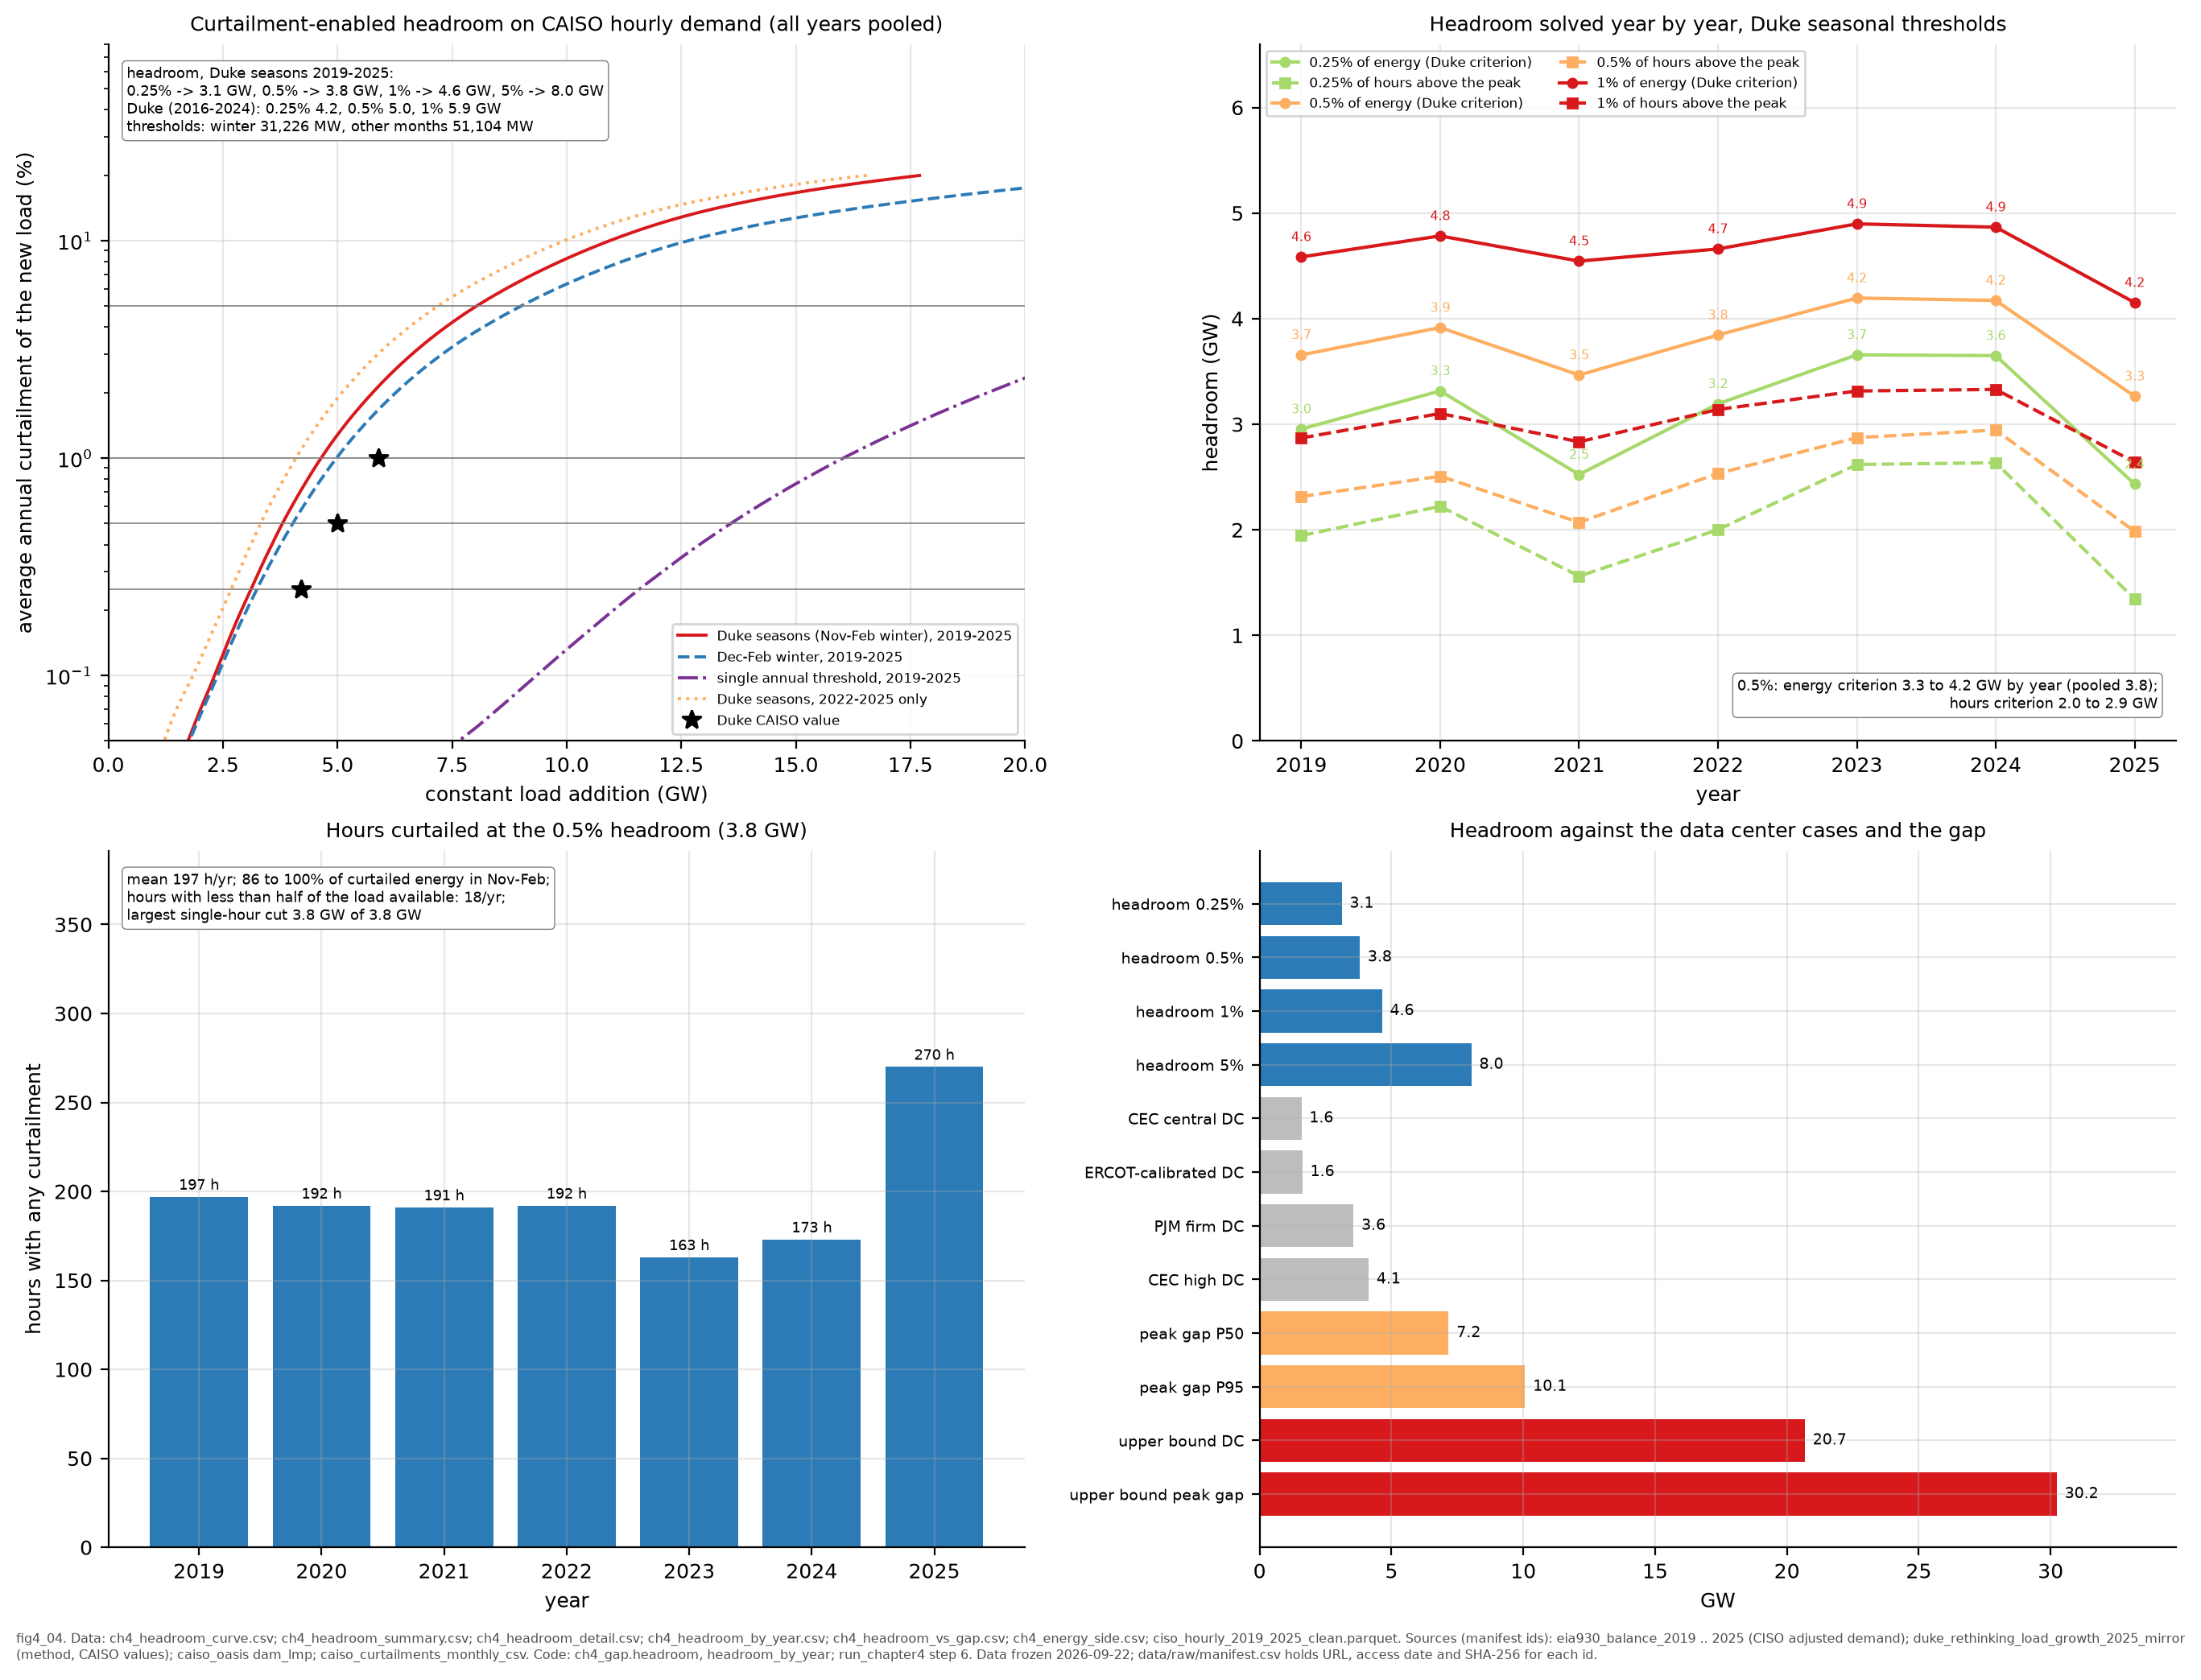

In [8]:
show("fig4_04_headroom")

**Reading.** On 2019-2025 CAISO demand the pooled headroom is 3.1 GW at 0.25 percent curtailment, 3.8 GW at 0.5 percent, 4.6 GW at 1 percent and 8.0 GW at 5 percent, against Duke's 4.2, 5.0 and 5.9 GW on 2016-2024 data; solved year by year, the energy criterion gives 3.3 to 4.2 GW at 0.5 percent and the stricter hours criterion 2.0 to 2.9 GW; the difference comes from the sample of years (the 2022-2025 subsample gives 2.7 to 4.1 GW) and the winter threshold, since 97 to 99 percent of the curtailment falls in November to February when winter evening loads sit close to the winter peak. At the 0.5 percent headroom the new load is curtailed in about 197 hours a year, in 18 of which less than half of it is available, and the largest single-hour cut is 3.8 GW. That headroom is 2.4 times the CEC's central data center addition, about equal to the PJM firm-only case, 53 percent of the median probability-weighted peak gap and 13 percent of the upper-bound peak gap. On the energy side, the SCE load-aggregation point had 877 negative-price day-ahead hours in 2025 (1,131 in 2024) and CAISO curtailed 3.8 TWh of wind and solar in 2025 and 4.9 TWh in January to August 2026, the equivalent of a 430 MW flat load running all year.

## 2. Regime crosswalk (RQ3)

In [9]:
table("ch4_regime_crosswalk")

,regime,granularity,stage_taxonomy,verification,timeliness,coverage,public_access,source_ids
0,CEC energization tiers (California),"MW by utility and tier, published as aggregates; project level only in SCE's public da...","three groups: signed agreement, active application, inquiry (2026 IEPR proposes a long...",utility-reported; no deposit or site-control test in the public record; confidence lev...,"annual IEPR data request (December 2024, summer 2025, December 2025 vintages); SCE dat...","no size threshold; seven utilities reported for the 2025 IEPR (VEA's 2,600 MW are in N...",docket documents and workshop decks; project-level detail confidential except SCE,cec_dc_methodology_memo_2026; cec_tn272026; cec_assembly_hearing_2026_01_28; cec_tn268459
1,ERCOT large load interconnection (Texas),"MW by status, load zone, TSP, project type, size class and in-service year; monthly sn...",no studies submitted; under ERCOT review; planning studies approved (Section 9.4/9.5 r...,TSP planning studies reviewed by ERCOT; observed energization measured from telemetry ...,"monthly (ERCOT Monthly, operational overview, NPRR1267 status report approved July 202...",loads of 75 MW or more at a point of interconnection (SB 6 threshold); 20 MW co-locate...,aggregated public reports; customer identities confidential,ercot_tac_2026_03_large_load_status; ercot_monthly_2025_11; ercot_ops_overview_2026_06...
2,PJM load forecast adjustments,"MW by zone and year 2026-2046 (Tables B-9, B-9b); firm and non-firm by zone in the LAS...",firm (electric service obligation or construction commitment) versus non-firm (letters...,"utility submissions reviewed by PJM: 70% utilization unless supported, ramps of at lea...","annual cycle (requests July, review September to November, forecast January)",large load adjustments submitted by transmission owners; no MW threshold stated in the...,"load report, tables and the Load Analysis Subcommittee decks are public; project lists...",pjm_lar_summary_2025_11_24; pjm_2026_load_forecast_report; pjm_2026_load_report_tables
3,EIA pilot data center surveys (federal),facility-level consumption for at least one data center per company (196 companies ide...,"operating facilities only; measures energy use, energy sources, site characteristics, ...","voluntary web survey (Texas, Washington) and interviews (Northern Virginia and DC)",pilot launched March 25 2026; no publication schedule yet,three regions; California not included,results not yet published; EIA states the aim of faster cycles and finer detail,eia_press585_dc_pilot_surveys
4,Texas SB 6 (2025),statute: disclosure duties per large load customer to the utility and ERCOT,interconnection standards to be set by the PUCT; PUCT rule 25.370 (March 2026) counts ...,disclosure of similar requests elsewhere in the state and of on-site backup generation...,standards and forecast rule in force from 2026; monthly ERCOT reporting continues,demand of 75 MW or more (the PUCT may lower it); curtailment service for loads of at l...,utilities barred from selling or sharing customer submissions except to the PUCT and E...,texas_sb6_2025_enrolled; ercot_house_hearing_2026_04_09
5,FERC Docket RM26-4 (federal),no data collection yet; the ANOPR (Oct 23 2025) proposes interconnection procedures fo...,"study, agreement and transition provisions modelled on Order No. 2023 (CAISO comments)...",to be set in each RTO/ISO tariff; the orders give the six RTOs/ISOs 60 days to justify...,ANOPR Oct 2025; comments Nov 2025; FERC committed to act by June 2026 (Apr 16 2026) an...,"transmission-connected loads above 20 MW in the six RTO/ISO regions, about two-thirds ...","docket filings public through eLibrary (ferc.gov rejects non-browser clients, so only ...",caiso_comments_ferc_rm26_4_2025_11; nerc_rm26_4_accelerated_plan_2026_03; ferc_news_20...


In [10]:
table("ch4_regime_scores")

,regime,granularity,stage_taxonomy,verification,timeliness,coverage,public_access,total
0,CEC energization tiers (California),1,2,1,1,3,2,10
1,ERCOT large load interconnection (Texas),2,3,2,3,2,1,13
2,PJM load forecast adjustments,2,1,2,1,1,1,8
3,EIA pilot data center surveys (federal),3,0,0,0,1,0,4
4,Texas SB 6 (2025),0,1,3,1,2,0,7
5,FERC Docket RM26-4 (federal),0,1,1,1,2,2,7


In [11]:
table("ch4_regime_rubric")

,criterion,rubric
0,granularity,"0 no data product; 1 aggregates by utility, zone or tier; 2 aggregates by phase, zone,..."
1,stage_taxonomy,0 operating facilities only; 1 one split (firm/non-firm or agreement/no agreement); 2 ...
2,verification,0 none or voluntary self-report; 1 utility or staff review without money at risk; 2 st...
3,timeliness,0 none or one-off pilot; 1 annual; 2 twice a year or quarterly; 3 monthly
4,coverage,0 none; 1 partial (three regions or submitted adjustments only); 2 all loads above a t...
5,public_access,0 not published or confidential; 1 aggregates only; 2 aggregates plus some project-lev...


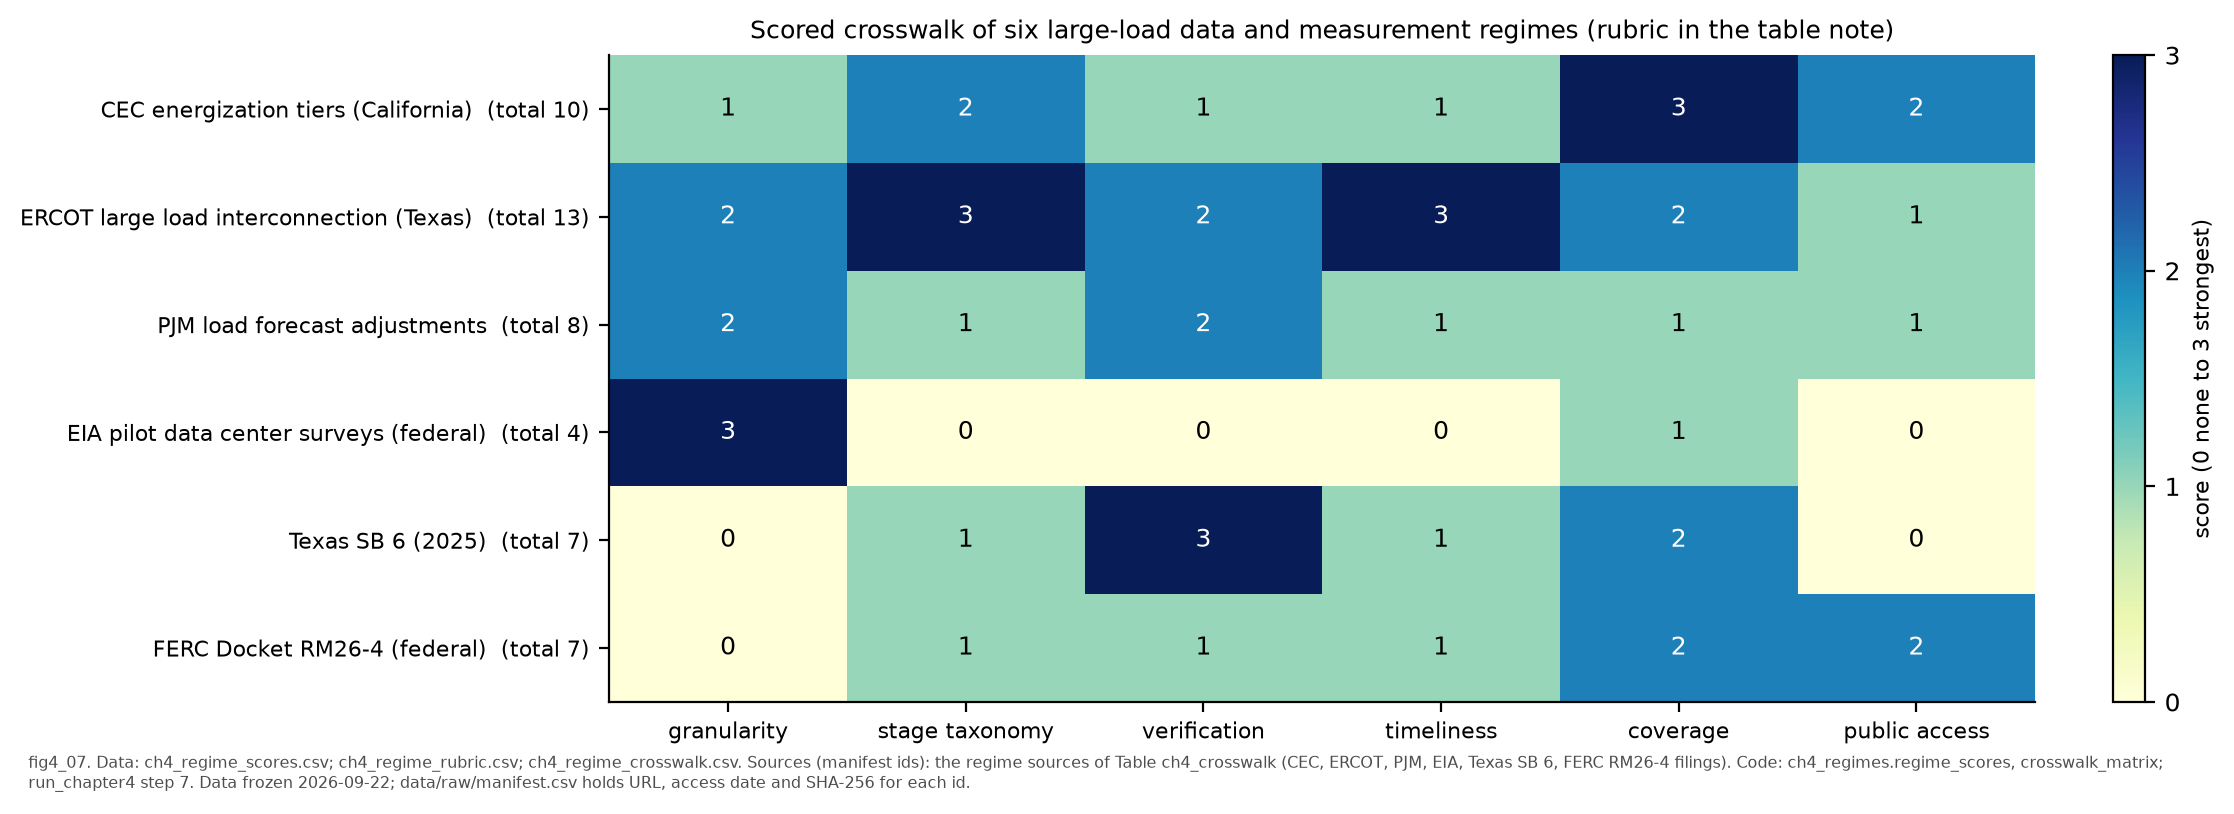

In [12]:
show("fig4_07_regime_scores")

In [13]:
table("ch4_common_taxonomy")

,common_stage,CEC tiers,ERCOT phases,PJM firm / non-firm,EIA pilot survey,Texas SB 6 / PUCT,FERC RM26-4
0,1 Inquiry or screening,Inquiry (Group 3),No studies submitted,not counted (no adjustment without an agreement),not applicable (operating facilities),screening study after the flat study fee,request submitted; study queue
1,2 Application and study,Active application (Group 2),Under ERCOT review,"non-firm: feasibility study, letter of authorization",not applicable,interconnection standards; intermediate agreement with site control and security (prop...,study process (60-day study proposed for flexible loads)
2,3 Agreement or financial commitment,Signed agreement (Group 1),Planning studies approved; Section 9.4/9.5 requirements met,firm: electric service obligation or construction commitment,not applicable,"interconnection agreement; USD 50,000/MW fee converts to non-refundable",interconnection agreement; cost responsibility for upgrades
3,4 Approved to energize or under construction,not distinguished (construction and initial energization in the 2026 milestone list),Approved to energize but not operational,firm with ramp of at least 36 months,not applicable,curtailment protocol before interconnection,transition provisions for loads already under study
4,5 Energized and observed,"existing load (about 1,000 MW peak, Dec 2025)",Observed energized (all-time non-simultaneous peak),embedded in the historical load,"surveyed consumption, energy sources, servers, cooling",curtailment during emergencies; telemetry to ERCOT,flexible service options


In [14]:
table("ch4_headline_by_regime").round(0)

,counting_rule,california_mw,what_is_counted,source
0,CEC: all three tiers,20677.0,"requested capacity, signed agreements plus applications plus inquiries, California-onl...",cec_assembly_hearing_2026_01_28; ch2_tier_vintages
1,CEC: all tiers including VEA (Nevada),23277.0,the CEC's published statewide total,cec_tn272026
2,CEC: agreements plus applications,12073.0,the comparison the CEC used between the 2024 and 2025 IEPR vintages,cec_prelim_dc_forecast_2025
3,ERCOT-style: every tracked request,20677.0,ERCOT reports all requests of 75 MW or more regardless of study status; the CEC tiers ...,ercot_tac_2026_03_large_load_status
4,ERCOT-style: energized by 2030 at the ERCOT hazards,2421.0,capacity expected to be energized within 60 months at the monthly phase-transition rat...,ch4_ercot_transition_rates
5,PUCT rule 25.370 (Texas forecast): executed agreements only,5086.0,only loads with an executed interconnection agreement enter the forecast after 2026,ercot_house_hearing_2026_04_09 slide 9
6,PJM-style: firm only,5086.0,electric service obligation or construction commitment; non-firm zero before 2030,pjm_lar_summary_2025_11_24
7,PJM-style: firm at 70% utilization (demand),3560.0,PJM converts requests to demand at 70% utilization,pjm_lar_summary_2025_11_24
8,Texas SB 6 threshold (75 MW and over),<NA>,not computable from the CEC aggregates; in SCE's project-level database 76% of active ...,texas_sb6_2025_enrolled; cec_tn268459
9,FERC RM26-4 threshold (above 20 MW),<NA>,not computable from the CEC aggregates; in SCE's database 95% of active requested MW i...,caiso_comments_ferc_rm26_4_2025_11; cec_tn268459


In [15]:
table("ch4_sce_size_classes").round(3)

,size_class,projects,requested_mw,share_of_active_mw,source
0,under 20 MW,28,179.642,0.035,"cec_tn268459 (SCE public database, Jan 29 2026; groups 1-3, 73 projects, 5,162 MW)"
1,20 to under 75 MW,23,1008.55,0.195,"cec_tn268459 (SCE public database, Jan 29 2026; groups 1-3, 73 projects, 5,162 MW)"
2,75 MW and over,21,3898.75,0.755,"cec_tn268459 (SCE public database, Jan 29 2026; groups 1-3, 73 projects, 5,162 MW)"


In [16]:
p = table("ch4_pjm_adjustments"); p[p.zone == "PJM RTO"].pivot(index="table", columns="year", values="mw")

year,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046
table,,,,,,,,,,,,,,,,,,,,,
B-9 adjustments above embedded,6403,10785,16242,22290,33707,41477,48772,55089,59889,63796,67370,71831,74809,76329,77450,78328,79123,79813,80496,81148,81810
B-9b total load associated with adjustments,11469,15856,21280,27361,38805,46638,53949,60258,65041,68968,72599,77020,79974,81519,82648,83601,84408,85120,85810,86503,87186


In [17]:
table("ch4_pjm_lar_chart_readings")

,year,request_mw,firm_mw,non_firm_mw,source
0,2026,14000,13000,0,"pjm_lar_summary_2025_11_24 slide 8, read from chart (approximate)"
1,2027,21000,18000,0,"pjm_lar_summary_2025_11_24 slide 8, read from chart (approximate)"
2,2028,32000,23000,0,"pjm_lar_summary_2025_11_24 slide 8, read from chart (approximate)"
3,2029,46000,27000,0,"pjm_lar_summary_2025_11_24 slide 8, read from chart (approximate)"
4,2030,60000,35000,5000,"pjm_lar_summary_2025_11_24 slide 8, read from chart (approximate)"
5,2031,72000,41000,10000,"pjm_lar_summary_2025_11_24 slide 8, read from chart (approximate)"
6,2032,82000,46000,14000,"pjm_lar_summary_2025_11_24 slide 8, read from chart (approximate)"
7,2035,98000,53000,21000,"pjm_lar_summary_2025_11_24 slide 8, read from chart (approximate)"
8,2040,110000,58000,25000,"pjm_lar_summary_2025_11_24 slide 8, read from chart (approximate)"
9,2046,115000,61000,27000,"pjm_lar_summary_2025_11_24 slide 8, read from chart (approximate)"


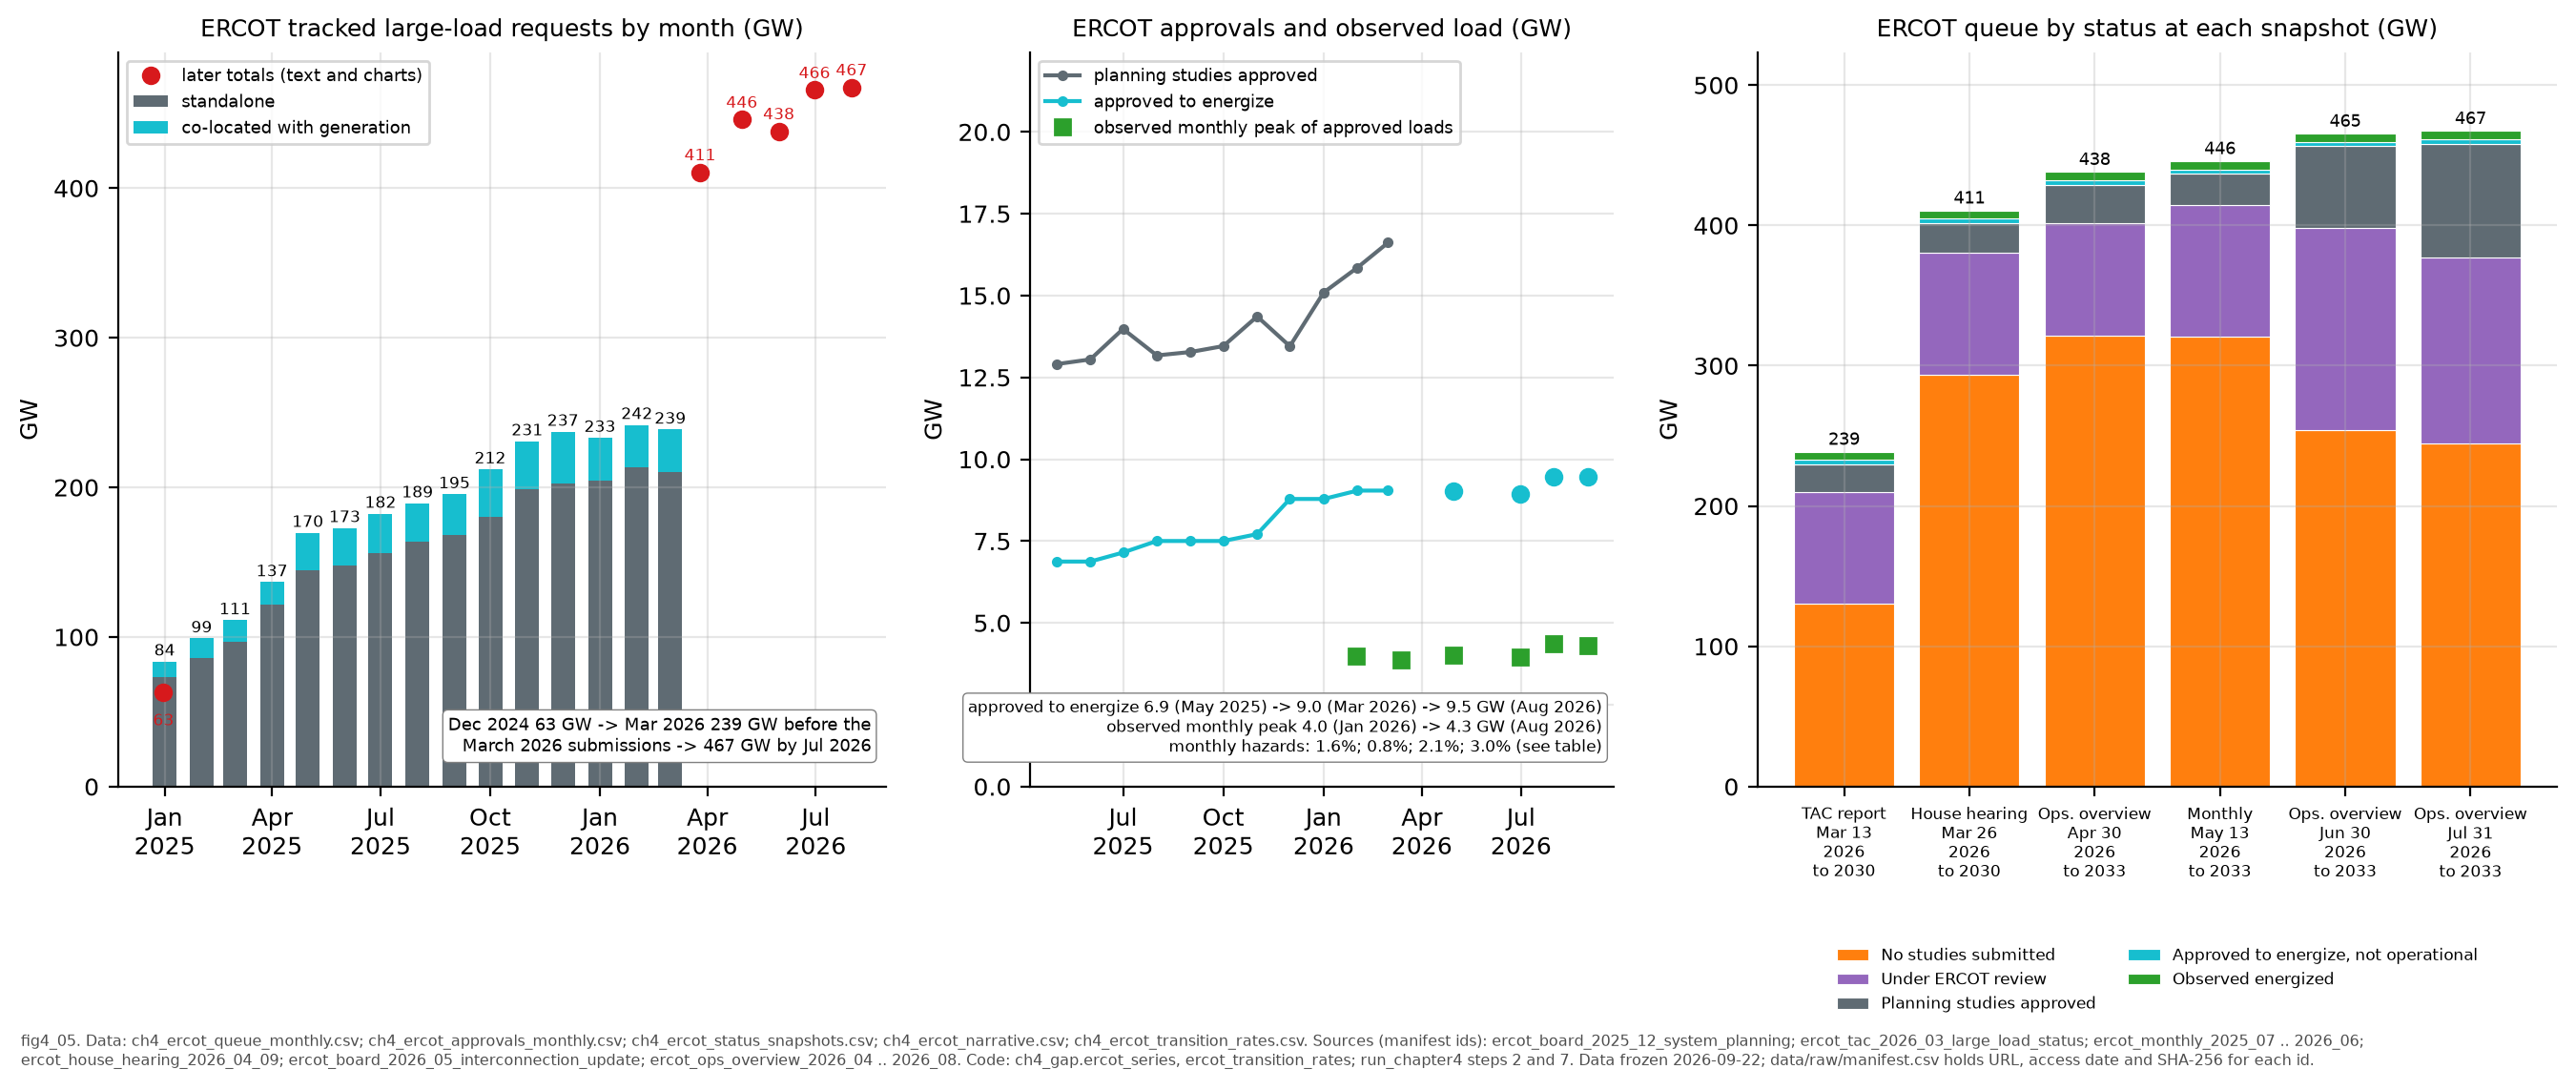

In [18]:
show("fig4_05_ercot_queue")

**Reading.** The same 20,677 MW is 20,677 MW under the CEC's and ERCOT's counting rules (both count every request regardless of study status), 5,086 MW under the PJM firm-only rule and the Texas forecast rule that admits only executed agreements after 2026 (3,560 MW of demand at PJM's 70 percent utilization), about 2,400 MW under ERCOT's realized phase-transition rates, and about 1,000 MW of measured existing load under a consumption survey like the EIA pilot. Thresholds cannot be applied to the CEC aggregates; in SCE's public project-level database 76 percent of active requested MW is in projects of 75 MW or more (the SB 6 threshold) and 95 percent in projects of 20 MW or more (the FERC ANOPR threshold).

## 3. Emissions of a flat versus a curtailable load (optional)

CAISO hourly accounting intensity (chapter 1, valid hours). A 1 MW load is either flat, curtailed to zero in the highest-intensity 5, 10 or 25 percent of hours (energy lost), or shifted, with the same energy moved from those hours to the lowest-intensity hours (load doubles there).

In [19]:
em = table("ch4_emissions_flat_vs_flexible"); em.pivot_table(index=["strategy", "share_hours"], columns="year", values="t_per_gwh").round(1)

year                   2023   2024   2025
strategy share_hours                     
curtail  0.05         232.5  187.3  175.5
         0.1          226.9  180.3  168.0
         0.25         210.0  158.9  146.3
flat     0.0          239.0  194.8  183.4
shift    0.05         223.5  176.1  164.9
         0.1          212.1  162.1  150.4
         0.25         189.5  132.9  120.6

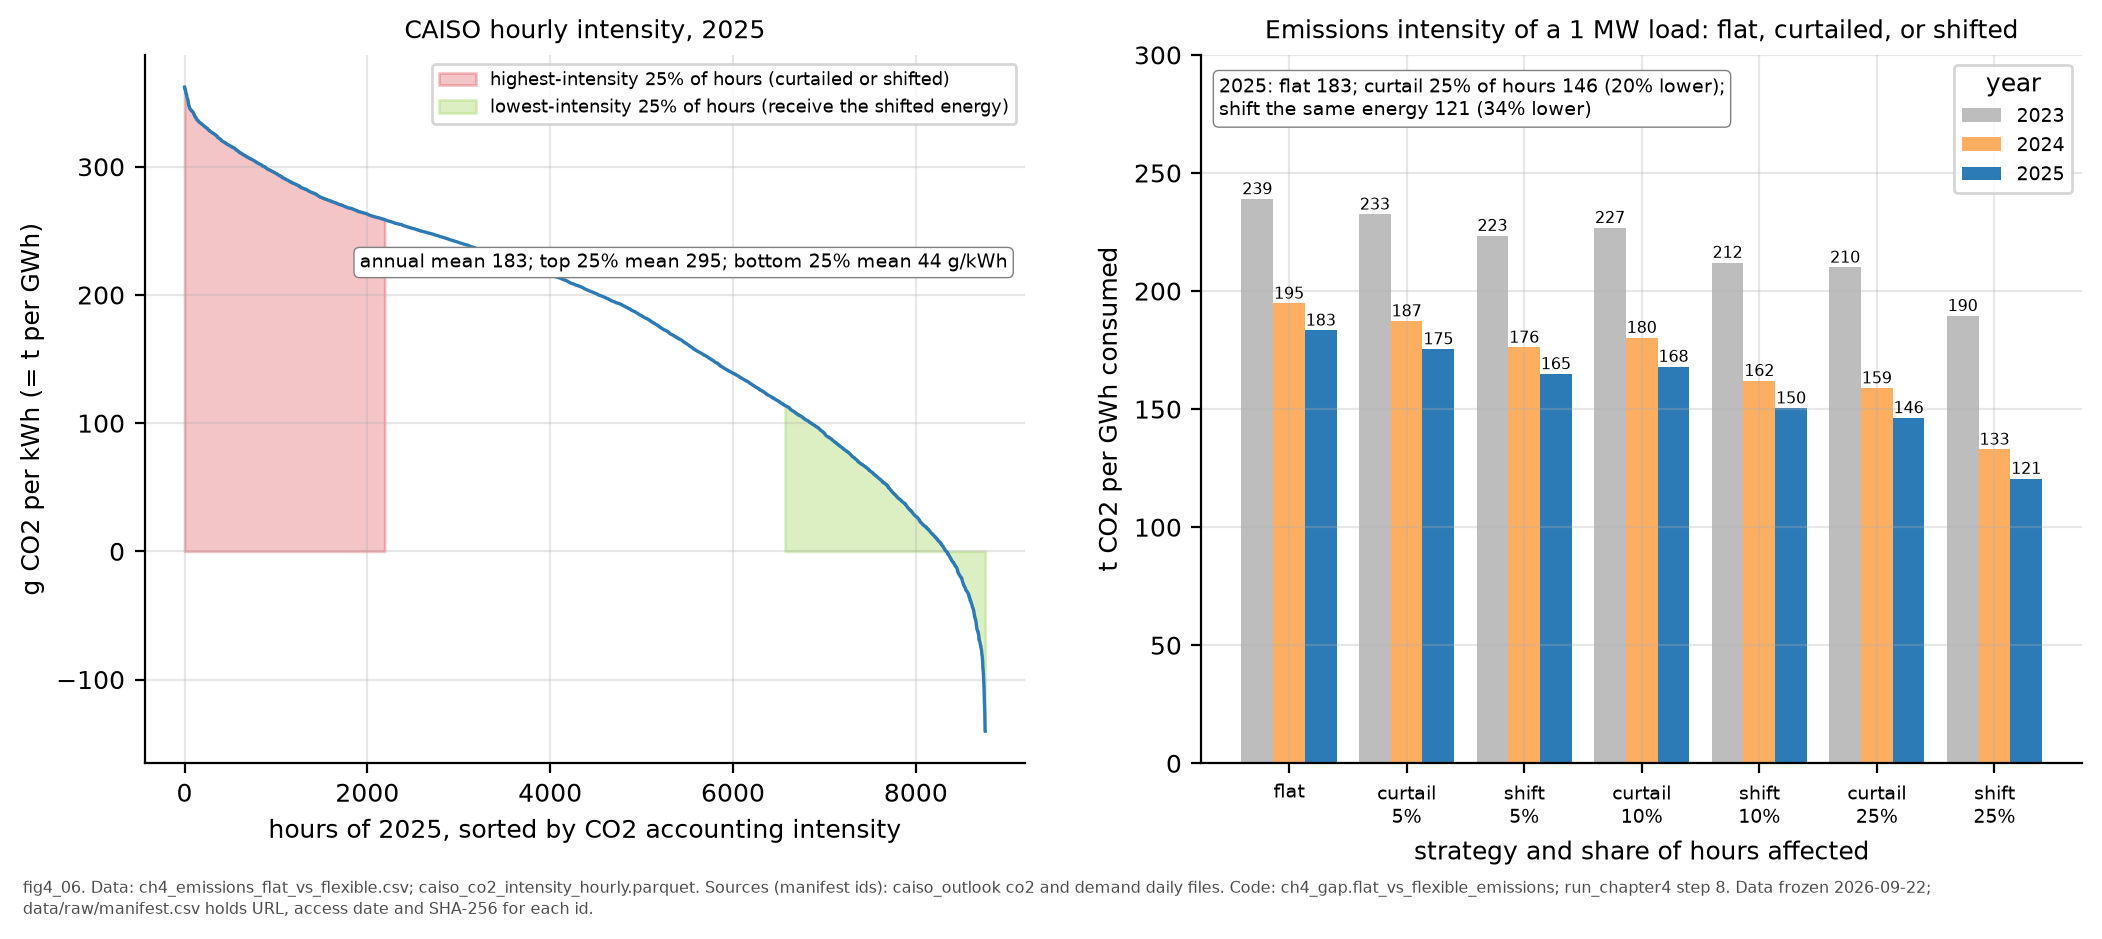

In [20]:
show("fig4_06_emissions_flat_vs_flexible")

**Reading.** A flat load carried 183 t CO2 per GWh in 2025 (239 in 2023). Curtailing it in the highest-intensity quarter of hours lowers the intensity of what it still consumes by 20 percent; shifting the same energy into the lowest-intensity quarter of hours, which had a mean accounting intensity of 44 g/kWh in 2025, lowers it by 34 percent to 121 t per GWh.